# DairyFlow AI — 01. Exploratory Data Analysis

Goal of this notebook: understand what's actually in `dairy_dataset.csv` before choosing a modeling
approach. The key question we're trying to answer is **"is this a dense time series we can forecast
per segment, or something sparser that needs a different approach?"** — the answer here directly
drives the modeling choice in notebook 03.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)

df = pd.read_csv("../dairy_dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])
print(df.shape)
df.head()


(4325, 23)


,Location,Total Land Area (acres),Number of Cows,Farm Size,Date,Product ID,Product Name,Brand,Quantity (liters/kg),Price per Unit,Total Value,Shelf Life (days),Storage Condition,Production Date,Expiration Date,Quantity Sold (liters/kg),Price per Unit (sold),Approx. Total Revenue(INR),Customer Location,Sales Channel,Quantity in Stock (liters/kg),Minimum Stock Threshold (liters/kg),Reorder Quantity (liters/kg)
0,Telangana,310.84,96,Medium,2022-02-17,5,Ice Cream,Dodla Dairy,222.40,85.72,19064.1280,25,Frozen,2021-12-27,2022-01-21,7,82.24,575.68,Madhya Pradesh,Wholesale,215,19.55,64.03
1,Uttar Pradesh,19.19,44,Large,2021-12-01,1,Milk,Amul,687.48,42.61,29293.5228,22,Tetra Pack,2021-10-03,2021-10-25,558,39.24,21895.92,Kerala,Wholesale,129,43.17,181.10
2,Tamil Nadu,581.69,24,Medium,2022-02-28,4,Yogurt,Dodla Dairy,503.48,36.50,18377.0200,30,Refrigerated,2022-01-14,2022-02-13,256,33.81,8655.36,Madhya Pradesh,Online,247,15.10,140.83
3,Telangana,908.00,89,Small,2019-06-09,3,Cheese,Britannia Industries,823.36,26.52,21835.5072,72,Frozen,2019-05-15,2019-07-26,601,28.92,17380.92,Rajasthan,Online,222,74.50,57.68
4,Maharashtra,861.95,21,Medium,2020-12-14,8,Buttermilk,Mother Dairy,147.77,83.85,12390.5145,11,Refrigerated,2020-10-17,2020-10-28,145,83.07,12045.15,Jharkhand,Retail,2,76.02,33.40


## Schema and data quality

In [2]:
df.dtypes


Location                                          str
Total Land Area (acres)                       float64
Number of Cows                                  int64
Farm Size                                         str
Date                                   datetime64[us]
Product ID                                      int64
Product Name                                      str
Brand                                             str
Quantity (liters/kg)                          float64
Price per Unit                                float64
Total Value                                   float64
Shelf Life (days)                               int64
Storage Condition                                 str
Production Date                                   str
Expiration Date                                   str
Quantity Sold (liters/kg)                       int64
Price per Unit (sold)                         float64
Approx. Total Revenue(INR)                    float64
Customer Location           

In [3]:
# missing values -- if this dataset is clean, it changes how much preprocessing notebook 02 needs
df.isnull().sum().to_frame("n_missing")


,n_missing
Location,0
Total Land Area (acres),0
Number of Cows,0
Farm Size,0
Date,0
Product ID,0
Product Name,0
Brand,0
Quantity (liters/kg),0
Price per Unit,0


In [4]:
print("Date range:", df['Date'].min().date(), "to", df['Date'].max().date())
print("Products:", df['Product Name'].nunique(), list(df['Product Name'].unique()))
print("Regions (states):", df['Location'].nunique())
print("Brands:", df['Brand'].nunique())


Date range: 2019-01-01 to 2022-12-28
Products: 10 ['Ice Cream', 'Milk', 'Yogurt', 'Cheese', 'Buttermilk', 'Curd', 'Paneer', 'Lassi', 'Ghee', 'Butter']
Regions (states): 15
Brands: 11


## Sparsity check — the finding that shapes everything downstream

If every product × region pair had a long, regular daily series, a per-segment ARIMA/Prophet model
would be the obvious choice. Let's check how much history actually exists per segment.


In [5]:
segment_counts = df.groupby(['Product Name', 'Location']).size()
print(segment_counts.describe())
print()
print("Total segments:", segment_counts.shape[0], "(", df['Product Name'].nunique(), "products x",
      df['Location'].nunique(), "regions )")


count    150.000000
mean      28.833333
std       10.258025
min       16.000000
25%       23.000000
50%       26.000000
75%       30.000000
max       67.000000
dtype: float64

Total segments: 150 ( 10 products x 15 regions )


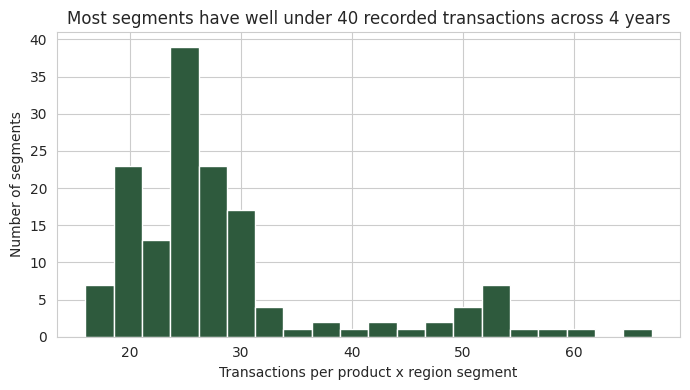

In [6]:
fig, ax = plt.subplots(figsize=(7,4))
segment_counts.hist(bins=20, ax=ax, color="#2E5A3D", edgecolor="white")
ax.set_xlabel("Transactions per product x region segment")
ax.set_ylabel("Number of segments")
ax.set_title("Most segments have well under 40 recorded transactions across 4 years")
plt.tight_layout()
plt.show()


**Conclusion**: median ~28 transactions per segment, spread irregularly over 4 years — too sparse for
a reliable per-segment time series model, and too irregular in timing to treat as a clean daily/weekly
series even after aggregation. This is the core justification for the hierarchical partial-pooling
approach used in notebook 03: pool statistical strength across products and regions rather than modeling
each segment alone.


## Demand distribution

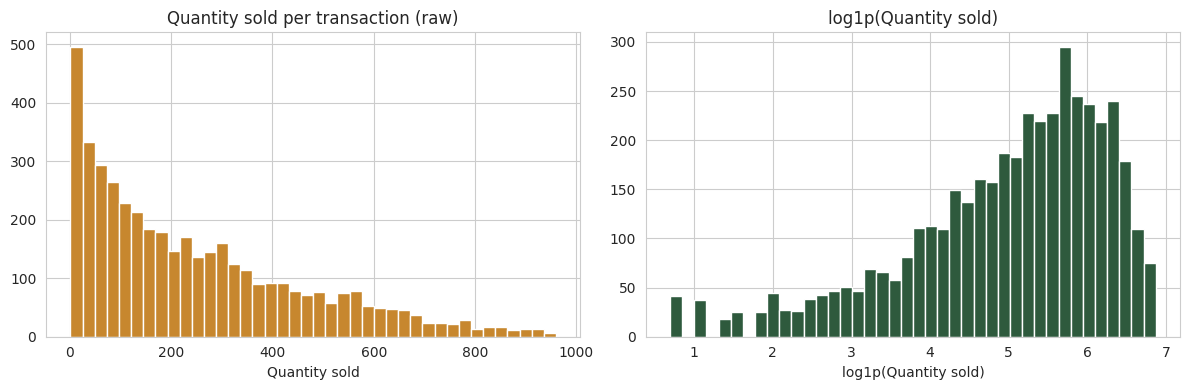

count    4325.000000
mean      248.095029
std       217.024182
min         1.000000
25%        69.000000
50%       189.000000
75%       374.000000
max       960.000000
Name: Quantity Sold (liters/kg), dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
df['Quantity Sold (liters/kg)'].hist(bins=40, ax=axes[0], color="#C7872E", edgecolor="white")
axes[0].set_title("Quantity sold per transaction (raw)")
axes[0].set_xlabel("Quantity sold")

np.log1p(df['Quantity Sold (liters/kg)']).hist(bins=40, ax=axes[1], color="#2E5A3D", edgecolor="white")
axes[1].set_title("log1p(Quantity sold)")
axes[1].set_xlabel("log1p(Quantity sold)")
plt.tight_layout()
plt.show()

print(df['Quantity Sold (liters/kg)'].describe())


Raw demand is right-skewed (a handful of very large batches pull the mean up) — a log transform brings
it much closer to symmetric, which is why notebook 02/03 model `log1p(quantity sold)` rather than the
raw quantity directly.


## Volume trend over time

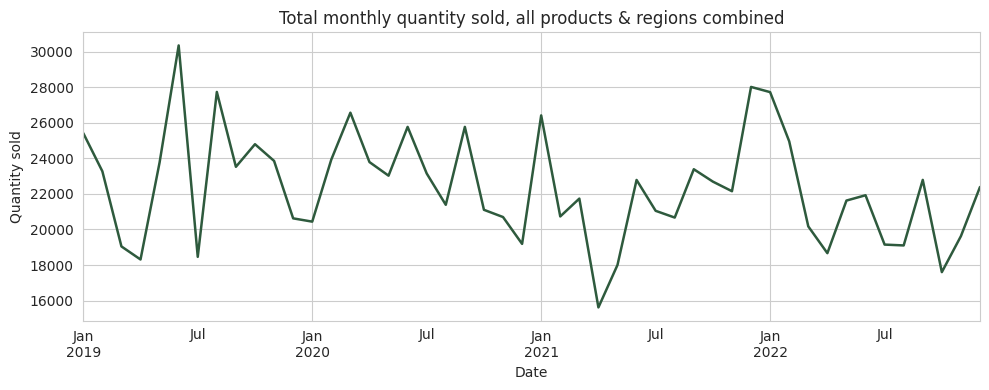

In [8]:
monthly = df.set_index('Date').resample('MS')['Quantity Sold (liters/kg)'].sum()
fig, ax = plt.subplots(figsize=(10,4))
monthly.plot(ax=ax, color="#2E5A3D", linewidth=1.8)
ax.set_title("Total monthly quantity sold, all products & regions combined")
ax.set_ylabel("Quantity sold")
plt.tight_layout()
plt.show()


## Product and region breakdowns

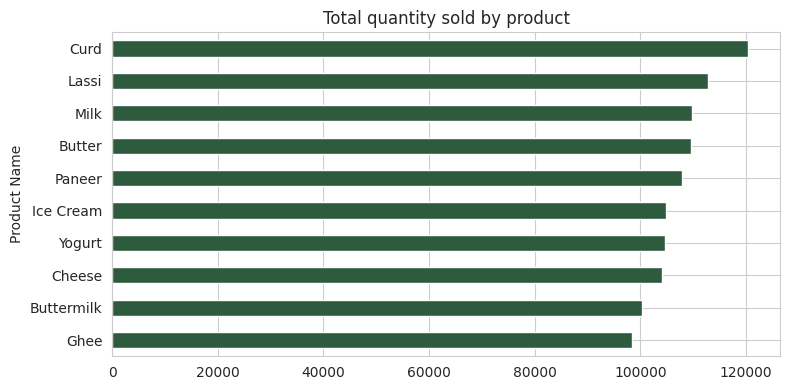

Product Name
Curd          120415
Lassi         112731
Milk          109852
Butter        109578
Paneer        107931
Ice Cream     104780
Yogurt        104744
Cheese        104065
Buttermilk    100402
Ghee           98513
Name: Quantity Sold (liters/kg), dtype: int64

In [9]:
by_product = df.groupby('Product Name')['Quantity Sold (liters/kg)'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8,4))
by_product.plot(kind='barh', ax=ax, color="#2E5A3D")
ax.invert_yaxis()
ax.set_title("Total quantity sold by product")
plt.tight_layout()
plt.show()
by_product


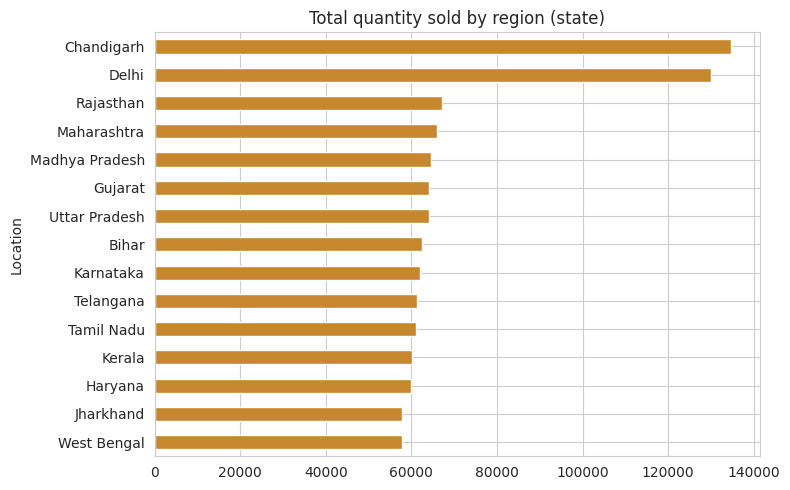

In [10]:
by_region = df.groupby('Location')['Quantity Sold (liters/kg)'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8,5))
by_region.plot(kind='barh', ax=ax, color="#C7872E")
ax.invert_yaxis()
ax.set_title("Total quantity sold by region (state)")
plt.tight_layout()
plt.show()


No single product or region dominates heavily — volume is fairly evenly spread, which is consistent
with the earlier sparsity finding: no segment has an outsized amount of history to lean on.


## The inventory-policy finding

This is the finding that ends up anchoring the whole pitch: compare the scale of `Minimum Stock
Threshold` against actual demand (`Quantity Sold`).


In [11]:
threshold = df['Minimum Stock Threshold (liters/kg)']
demand = df['Quantity Sold (liters/kg)']

print("Minimum Stock Threshold -- mean: {:.1f}, range: [{:.0f}, {:.0f}]".format(
    threshold.mean(), threshold.min(), threshold.max()))
print("Quantity Sold          -- mean: {:.1f}, range: [{:.0f}, {:.0f}]".format(
    demand.mean(), demand.min(), demand.max()))

pct_below = (df['Quantity in Stock (liters/kg)'] < df['Minimum Stock Threshold (liters/kg)']).mean() * 100
n_below = (df['Quantity in Stock (liters/kg)'] < df['Minimum Stock Threshold (liters/kg)']).sum()
print(f"\n{n_below} of {len(df)} records ({pct_below:.1f}%) already sit below the minimum stock threshold.")


Minimum Stock Threshold -- mean: 55.8, range: [10, 100]
Quantity Sold          -- mean: 248.1, range: [1, 960]

918 of 4325 records (21.2%) already sit below the minimum stock threshold.


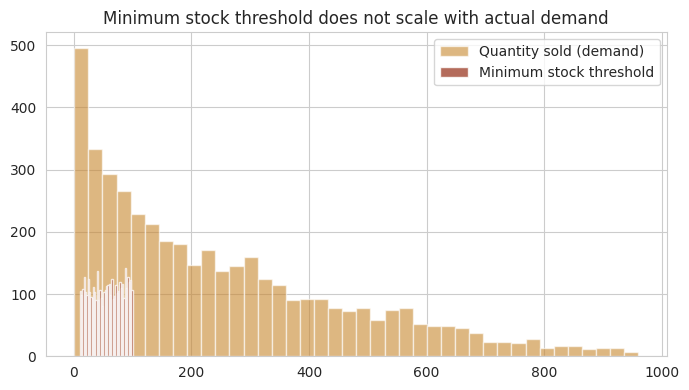

In [12]:
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(demand, bins=40, alpha=0.6, label="Quantity sold (demand)", color="#C7872E")
ax.hist(threshold, bins=40, alpha=0.8, label="Minimum stock threshold", color="#A24632")
ax.set_title("Minimum stock threshold does not scale with actual demand")
ax.legend()
plt.tight_layout()
plt.show()


**This is the headline finding**: the minimum stock threshold sits almost entirely below 100 units
regardless of product or region, while demand routinely runs into the hundreds. The current policy
applies roughly the same small buffer everywhere, independent of how much a segment actually sells —
which is a large part of *why* 21% of records already show stock below threshold. A model-driven,
segment-specific reorder point (built in notebook 03) directly addresses this.


## Shelf life & storage

/tmp/ipykernel_589/315067061.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Storage Condition', y='Shelf Life (days)', ax=ax,
/tmp/ipykernel_589/315067061.py:2: UserWarning: 
The palette list has fewer values (3) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df, x='Storage Condition', y='Shelf Life (days)', ax=ax,


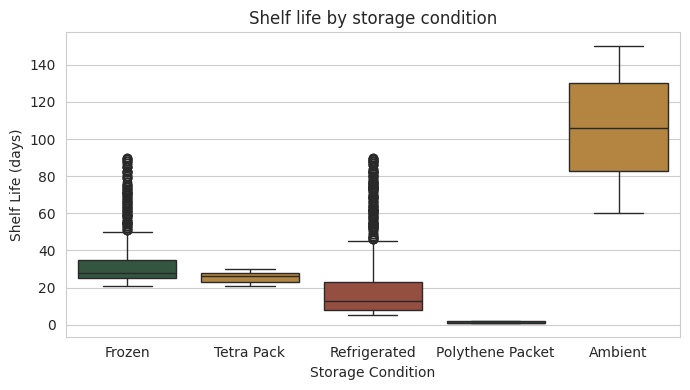

In [13]:
fig, ax = plt.subplots(figsize=(7,4))
sns.boxplot(data=df, x='Storage Condition', y='Shelf Life (days)', ax=ax,
            palette=["#2E5A3D", "#C7872E", "#A24632"])
ax.set_title("Shelf life by storage condition")
plt.tight_layout()
plt.show()


## Summary

- 4,325 transactions, no missing values, 4-year span, 10 products x 15 regions = 150 segments.
- **Sparse and irregular**: median ~28 transactions per segment — rules out per-segment time series
  models, motivates hierarchical partial pooling (notebook 03).
- **Right-skewed demand**: log1p transform needed before modeling (notebook 02).
- **Threshold-demand scale mismatch**: the current inventory policy doesn't scale with real demand —
  this is a genuine data finding, not a modeling artifact, and it's the strongest single number for
  the pitch.

Next: [`02_feature_engineering.ipynb`](./02_feature_engineering.ipynb)
